In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/BurstGPT_1.csv')

In [2]:
df_chatgpt = df[df['Model'] == 'ChatGPT']
df_gpt4 = df[df['Model'] == 'GPT-4']

# Requests pattern

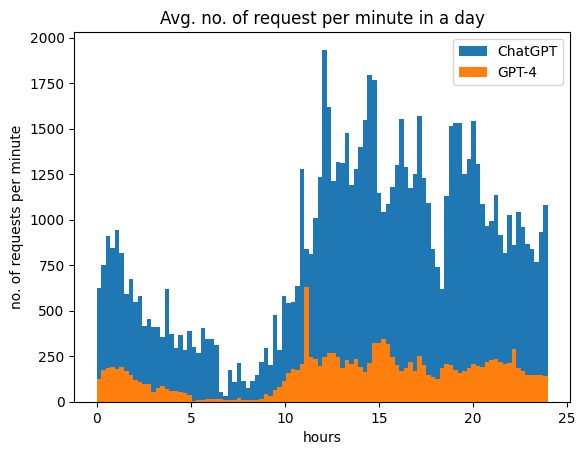

In [3]:
bins = 100

chatgpt_minute_timestamp = df_chatgpt.Timestamp % (3600 * 24) / 60
chatgpt_hour_timestamp = chatgpt_minute_timestamp / 60
counts, edges = np.histogram(chatgpt_hour_timestamp, bins=bins)
_ = plt.stairs(bins * counts / (chatgpt_minute_timestamp.max() - chatgpt_minute_timestamp.min()), edges=edges, label='ChatGPT', fill=True)

gpt4_minute_timestamp = df_gpt4.Timestamp % (3600 * 24) / 60
gpt4_hour_timestamp = gpt4_minute_timestamp / 60
counts, edges = np.histogram(gpt4_hour_timestamp, bins=bins)
_ = plt.stairs(bins * counts / (gpt4_minute_timestamp.max() - gpt4_minute_timestamp.min()), edges=edges, label='GPT-4', fill=True)

plt.title("Avg. no. of request per minute in a day")
plt.ylabel("no. of requests per minute")
plt.xlabel("hours")
plt.legend()

In [4]:
print("chatGPT requests count:", len(df_chatgpt))
print("gpt4 requests count:", len(df_gpt4))

chatGPT requests count: 1210109
gpt4 requests count: 219628


In [5]:
print('average wait time for the next ChatGPT request', df_chatgpt.Timestamp.diff().mean())
print('average wait time for the next GPT-4 request', df_gpt4.Timestamp.diff().mean())
print('average wait time for the next request (All)', df.Timestamp.diff().mean())

average wait time for the next ChatGPT request 4.354956747662192
average wait time for the next GPT-4 request 23.993265855291018
average wait time for the next request (All) 3.6859727949775345


# Token Pattern

(0.0, 500.0)

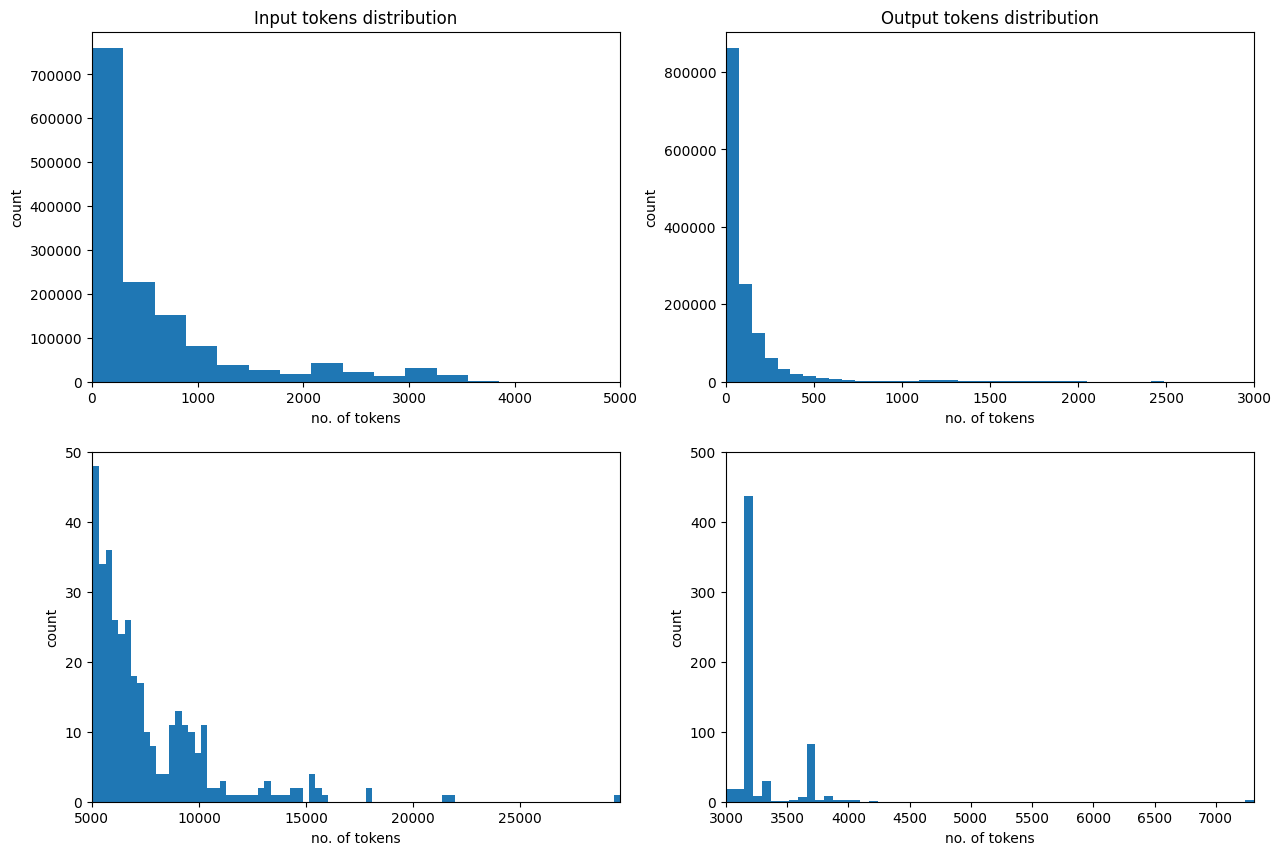

In [6]:
counts, edges = np.histogram(df['Request tokens'], bins=100)

plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.stairs(counts, edges=edges, fill=True)
plt.title("Input tokens distribution")
plt.xlabel("no. of tokens")
plt.ylabel("count")
plt.xlim([0, 5000])

plt.subplot(2, 2, 3)
plt.stairs(counts, edges=edges, fill=True)
plt.xlabel("no. of tokens")
plt.ylabel("count")
plt.xlim([5000, edges[-1]])
plt.ylim([0, 50])

counts, edges = np.histogram(df['Response tokens'], bins=100)
plt.subplot(2, 2, 2)
plt.stairs(counts, edges=edges, fill=True)
plt.title("Output tokens distribution")
plt.xlabel("no. of tokens")
plt.ylabel("count")
plt.xlim([0, 3000])

plt.subplot(2, 2, 4)
plt.stairs(counts, edges=edges, fill=True)
plt.xlabel("no. of tokens")
plt.ylabel("count")
plt.xlim([3000, edges[-1]])
plt.ylim([0, 500])

In [7]:
print("max no. of tokens in a request:", df['Request tokens'].max())
print("max no. of tokens in a response:", df['Response tokens'].max())

max no. of tokens in a request: 29665
max no. of tokens in a response: 7315


# References:

BurstGPT Paper: https://arxiv.org/pdf/2401.17644 \
BurstGPT Github: https://github.com/HPMLL/BurstGPT?tab=readme-ov-file